In [ ]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
from warnings import filterwarnings
filterwarnings("ignore")

In [ ]:
# Load Dataset

df = pd.read_csv("../data/banking_cleaned.csv")

In [3]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,dob,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,...,1988-03-09,36.011293,-82.048315,0,38,26-40,2019,January,Tuesday,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,...,1978-06-21,49.159047,-118.186462,0,48,41-60,2019,January,Tuesday,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,...,1962-01-19,43.150704,-112.154481,0,64,60+,2019,January,Tuesday,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,...,1967-01-12,47.034331,-112.561071,0,59,41-60,2019,January,Tuesday,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,...,1986-03-28,38.674999,-78.632459,0,40,26-40,2019,January,Tuesday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,Hatch,UT,37.7175,-112.4777,...,1961-11-24,36.841266,-111.690765,0,64,60+,2020,June,Sunday,12
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,Tuscarora,MD,39.2667,-77.5101,...,1979-12-11,38.906881,-78.246528,0,46,41-60,2020,June,Sunday,12
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,High Rolls Mountain Park,NM,32.9396,-105.8189,...,1967-08-30,33.619513,-105.130529,0,58,41-60,2020,June,Sunday,12
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,Manderson,SD,43.3526,-102.5411,...,1980-08-18,42.788940,-103.241160,0,45,41-60,2020,June,Sunday,12


In [4]:
# Data Inspections
df.shape



(1296675, 22)

In [5]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   gender                 1296675 non-null  object 
 6   city                   1296675 non-null  object 
 7   state                  1296675 non-null  object 
 8   lat                    1296675 non-null  float64
 9   long                   1296675 non-null  float64
 10  city_pop               1296675 non-null  int64  
 11  job                    1296675 non-null  object 
 12  dob                    1296675 non-null  object 
 13  merch_lat              1296675 non-null  float64
 14  merch_long        

In [6]:
df.describe()

,cc_num,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,Age,Year,Hour
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,4.171920e+17,7.035104e+01,3.853762e+01,-9.022634e+01,8.882444e+04,3.853734e+01,-9.022646e+01,5.788652e-03,5.225753e+01,2.019287e+03,1.280486e+01
std,1.308806e+18,1.603160e+02,5.075808e+00,1.375908e+01,3.019564e+05,5.109788e+00,1.377109e+01,7.586269e-02,1.740842e+01,4.522452e-01,6.817824e+00
min,6.041621e+10,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902779e+01,-1.666712e+02,0.000000e+00,2.100000e+01,2.019000e+03,0.000000e+00
25%,1.800429e+14,9.650000e+00,3.462050e+01,-9.679800e+01,7.430000e+02,3.473357e+01,-9.689728e+01,0.000000e+00,3.900000e+01,2.019000e+03,7.000000e+00
50%,3.521417e+15,4.752000e+01,3.935430e+01,-8.747690e+01,2.456000e+03,3.936568e+01,-8.743839e+01,0.000000e+00,5.000000e+01,2.019000e+03,1.400000e+01
75%,4.642255e+15,8.314000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195716e+01,-8.023680e+01,0.000000e+00,6.300000e+01,2.020000e+03,1.900000e+01
max,4.992346e+18,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,1.010000e+02,2.020000e+03,2.300000e+01


In [7]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,dob,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,...,1988-03-09,36.011293,-82.048315,0,38,26-40,2019,January,Tuesday,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,...,1978-06-21,49.159047,-118.186462,0,48,41-60,2019,January,Tuesday,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,...,1962-01-19,43.150704,-112.154481,0,64,60+,2019,January,Tuesday,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,...,1967-01-12,47.034331,-112.561071,0,59,41-60,2019,January,Tuesday,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,...,1986-03-28,38.674999,-78.632459,0,40,26-40,2019,January,Tuesday,0


In [8]:
df.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,dob,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,Hatch,UT,37.7175,-112.4777,...,1961-11-24,36.841266,-111.690765,0,64,60+,2020,June,Sunday,12
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,Tuscarora,MD,39.2667,-77.5101,...,1979-12-11,38.906881,-78.246528,0,46,41-60,2020,June,Sunday,12
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,High Rolls Mountain Park,NM,32.9396,-105.8189,...,1967-08-30,33.619513,-105.130529,0,58,41-60,2020,June,Sunday,12
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,Manderson,SD,43.3526,-102.5411,...,1980-08-18,42.788940,-103.241160,0,45,41-60,2020,June,Sunday,12
1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,M,Sula,MT,45.8433,-113.8748,...,1995-08-16,46.565983,-114.186110,0,30,26-40,2020,June,Sunday,12


In [9]:
# checking nulls
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
gender                   0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
merch_lat                0
merch_long               0
is_fraud                 0
Age                      0
Age_Group                0
Year                     0
Month                    0
Day                      0
Hour                     0
dtype: int64

In [10]:
# checking  duplicates

df.duplicated().sum()

np.int64(0)

In [11]:
#  Fraud Distribution
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [12]:
# Outliers Analysis

num_cols = [
    'amt',
    'city_pop',
    'Age',
    'lat',
    'long',
    'merch_lat',
    'merch_long'
]

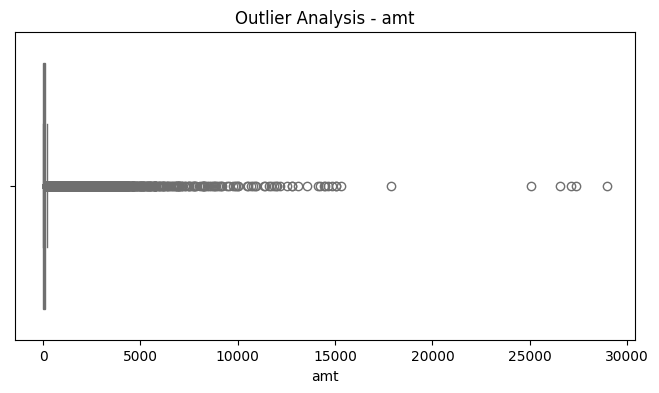

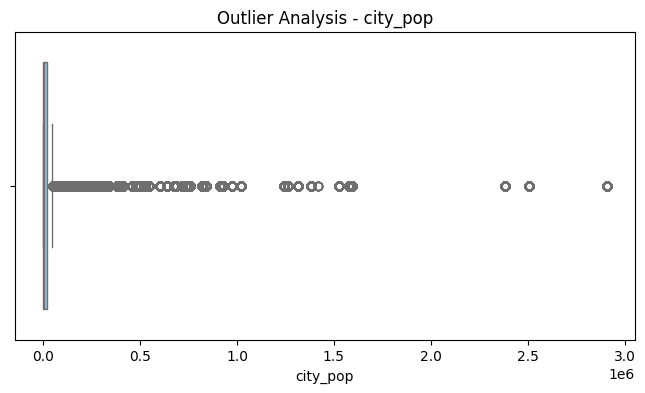

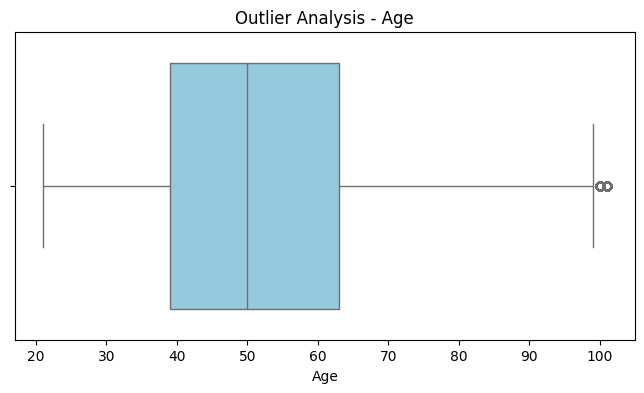

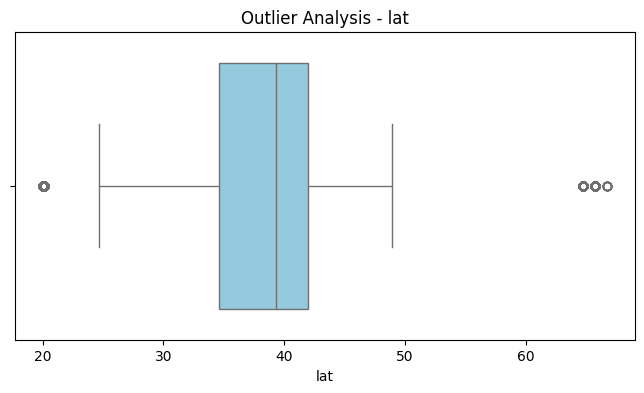

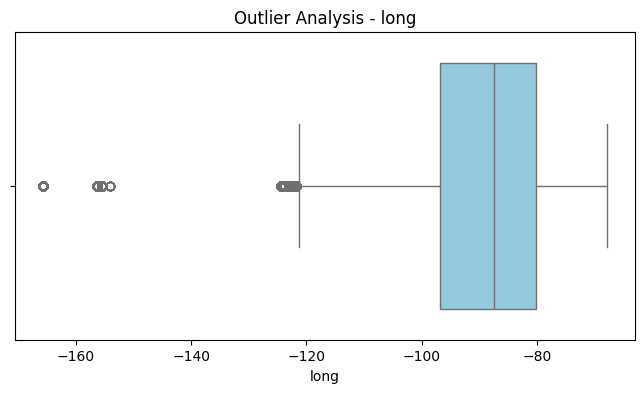

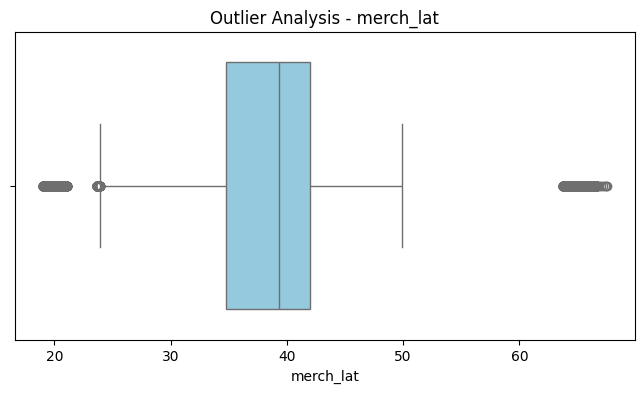

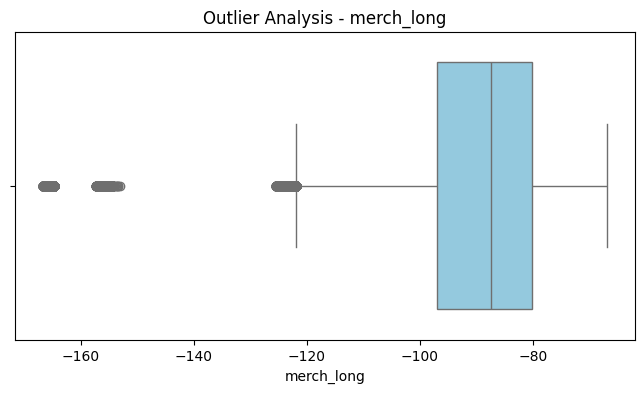

In [13]:
# Boxplots for Outliers

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(
        x=df[col],
        color='skyblue'
    )
    plt.title(f'Outlier Analysis - {col}')
    plt.show()

In [14]:
# IQR Method
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col)
    print("Outliers:", len(outliers))
    print("-------------------")


amt
Outliers: 67290
-------------------
city_pop
Outliers: 242674
-------------------
Age
Outliers: 4578
-------------------
lat
Outliers: 4679
-------------------
long
Outliers: 49922
-------------------
merch_lat
Outliers: 4967
-------------------
merch_long
Outliers: 41994
-------------------


## Visualization

### Univariate Analysis

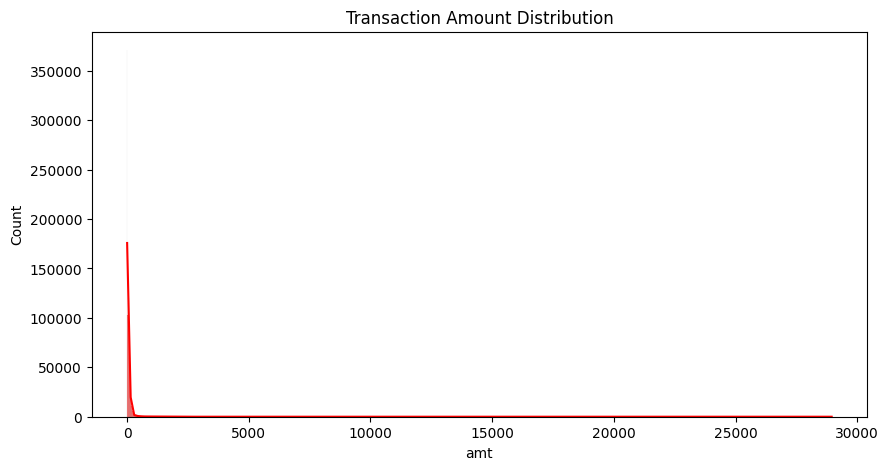

In [15]:
# Distribution of Transaction Amount

plt.figure(figsize=(10,5))

sns.histplot(
    data=df, x='amt', kde=True, color="red"
)

plt.title('Transaction Amount Distribution')
plt.show()

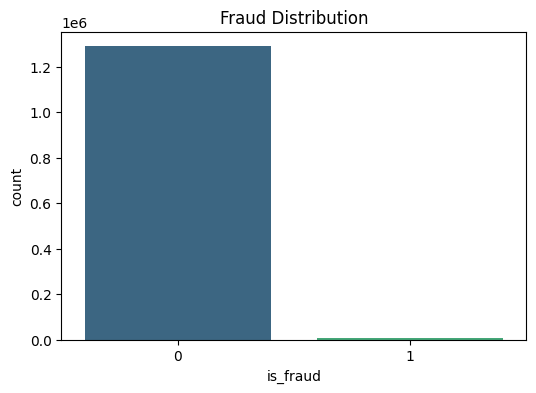

In [16]:
# Fraud Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='is_fraud',
    hue='is_fraud',
    palette='viridis',
    legend=False
)

plt.title('Fraud Distribution')
plt.show()

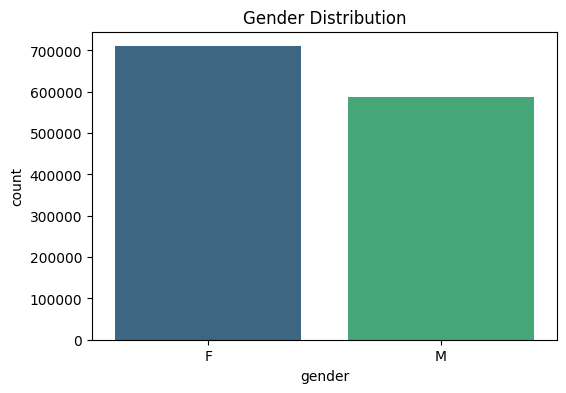

In [17]:
# Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='gender',
    hue="gender",
    palette='viridis'
)

plt.title('Gender Distribution')
plt.show()

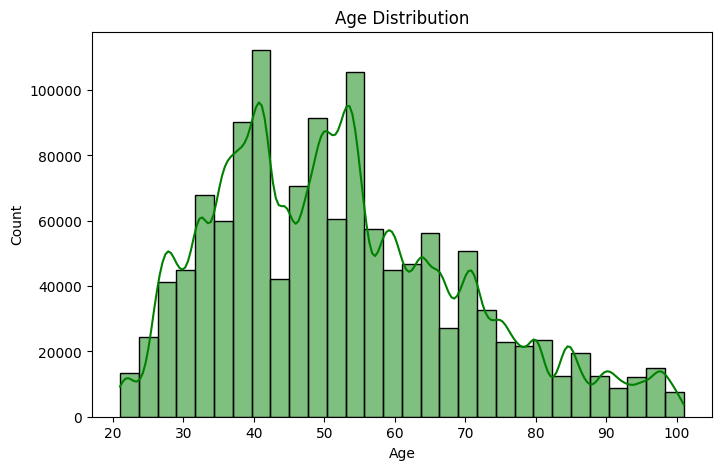

In [18]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    bins=30,
    kde=True,
    color="green"
)

plt.title('Age Distribution')
plt.show()

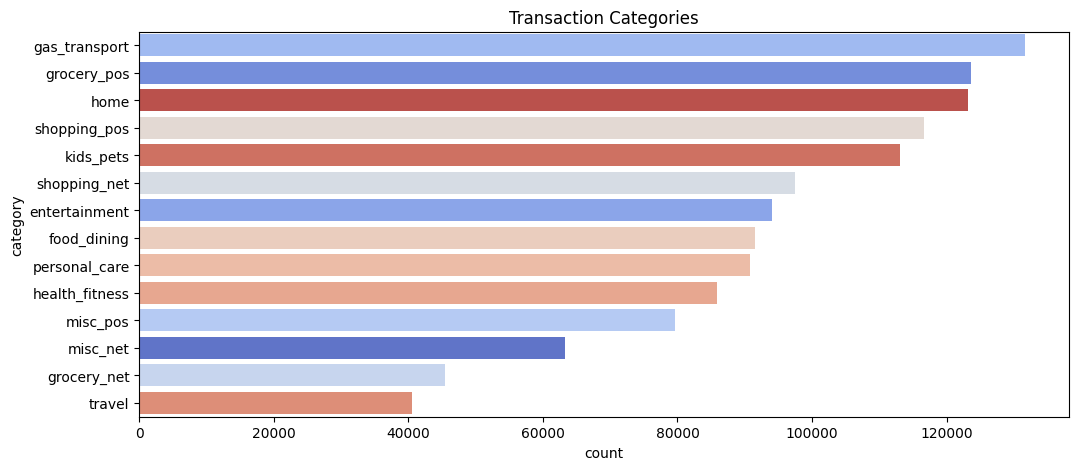

In [19]:
# Category Distribution

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index,
    hue="category",
    palette='coolwarm'
)

plt.title('Transaction Categories')
plt.show()

###  Bivariate Analysis


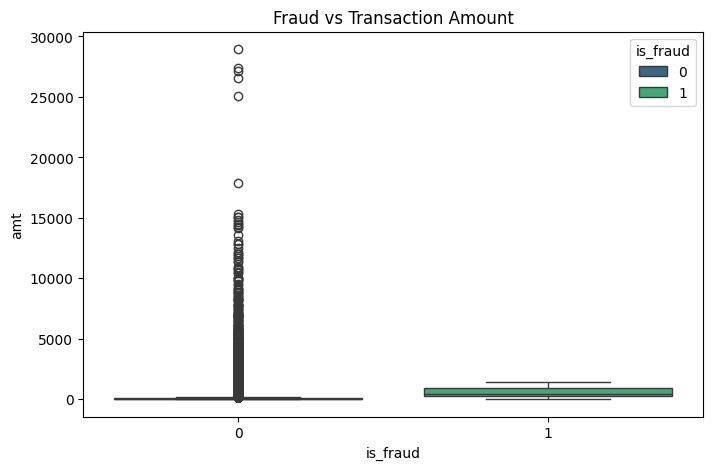

In [20]:
# Fraud vs Amount
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='amt',
    hue="is_fraud",
    palette='viridis'
)

plt.title('Fraud vs Transaction Amount')
plt.show()

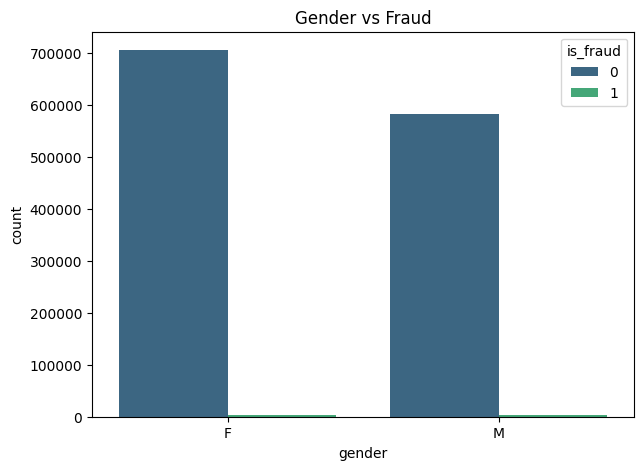

In [21]:
# Gender vs Fraud

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='gender',
    hue='is_fraud',
    palette='viridis'
)

plt.title('Gender vs Fraud')
plt.show()

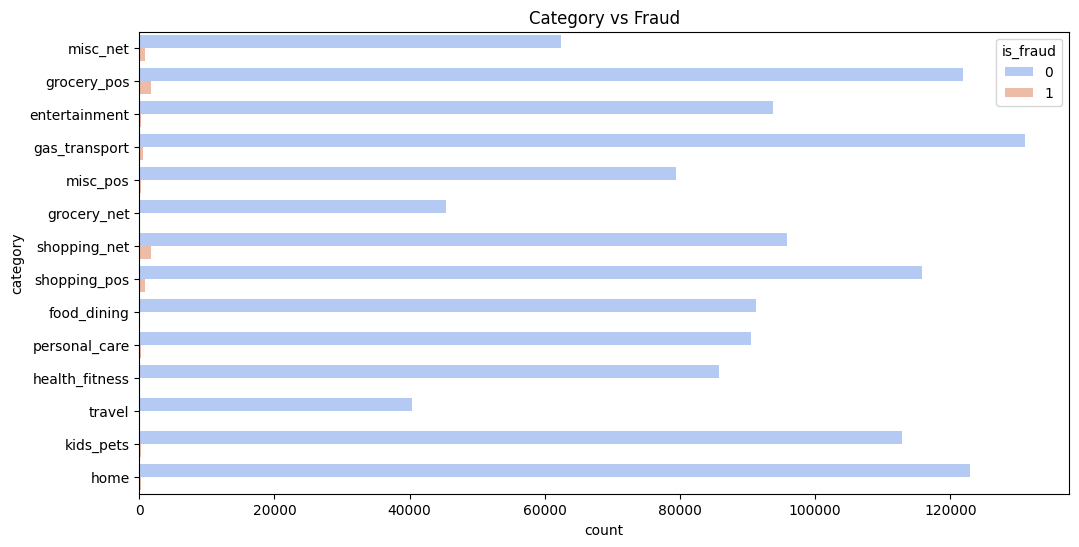

In [22]:
# Category vs Fraud
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='category',
    hue='is_fraud',
    palette='coolwarm'
)

plt.title('Category vs Fraud')
plt.show()

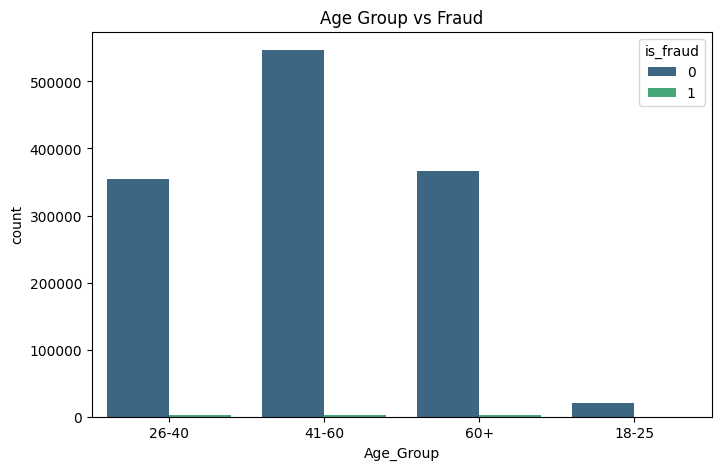

In [23]:
# Age Group vs Fraud
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Age_Group',
    hue='is_fraud',
    palette='viridis'
)

plt.title('Age Group vs Fraud')
plt.show()

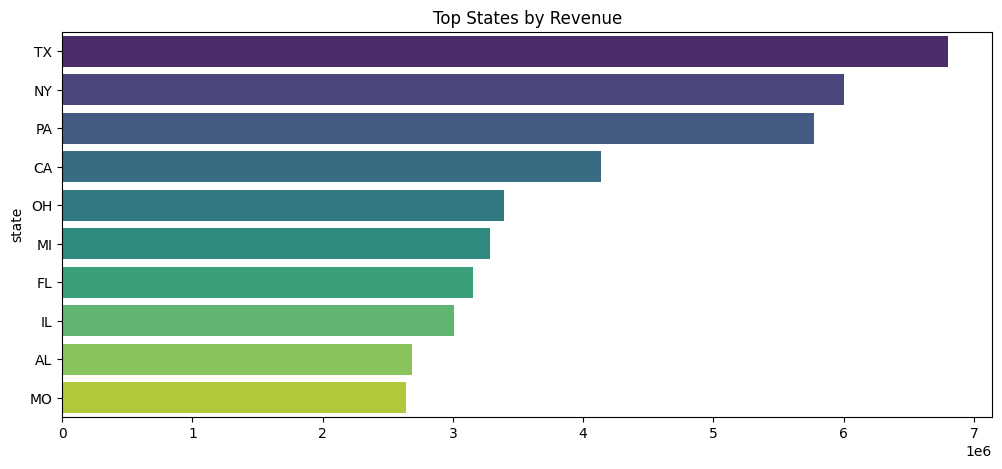

In [24]:
# State vs Revenue
state_amt = (
    df.groupby('state')['amt']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=state_amt.values,
    y=state_amt.index,
    hue=state_amt.index,
    palette='viridis',
    legend=False
)

plt.title('Top States by Revenue')
plt.show()

### Multivariate Analysis

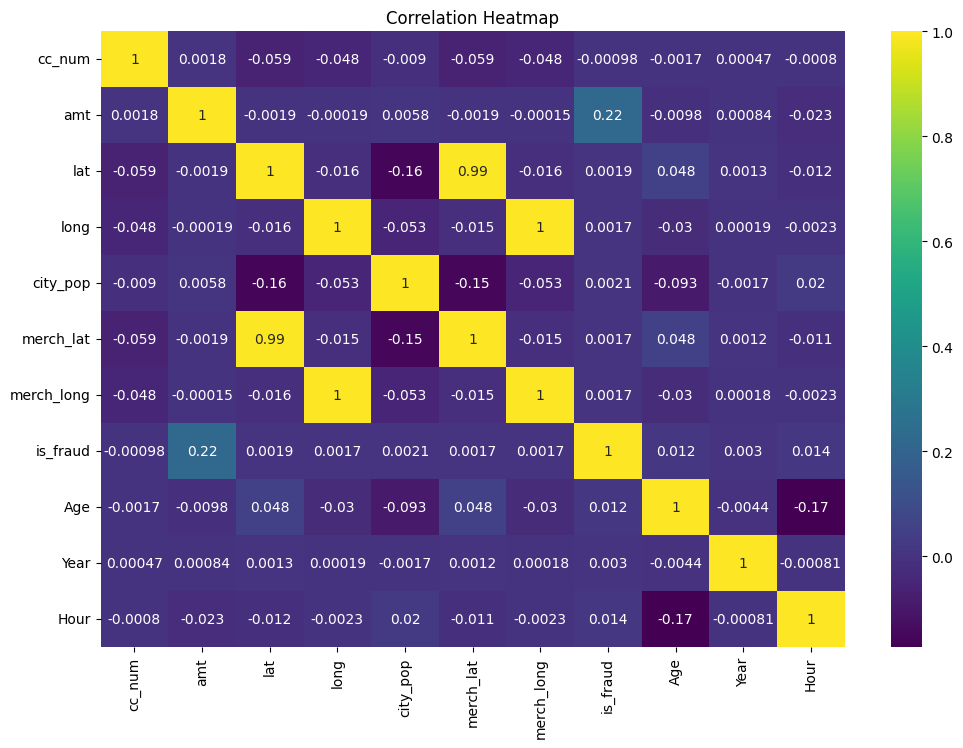

In [25]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='viridis'
)

plt.title('Correlation Heatmap')
plt.show()

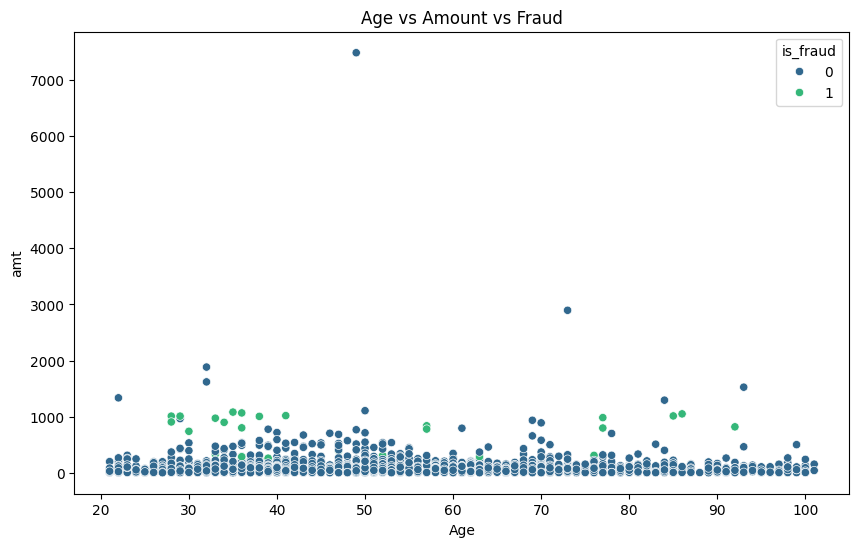

In [26]:
# Amount vs Age vs Fraud

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x='Age',
    y='amt',
    hue='is_fraud',
    palette='viridis'
)

plt.title('Age vs Amount vs Fraud')
plt.show()

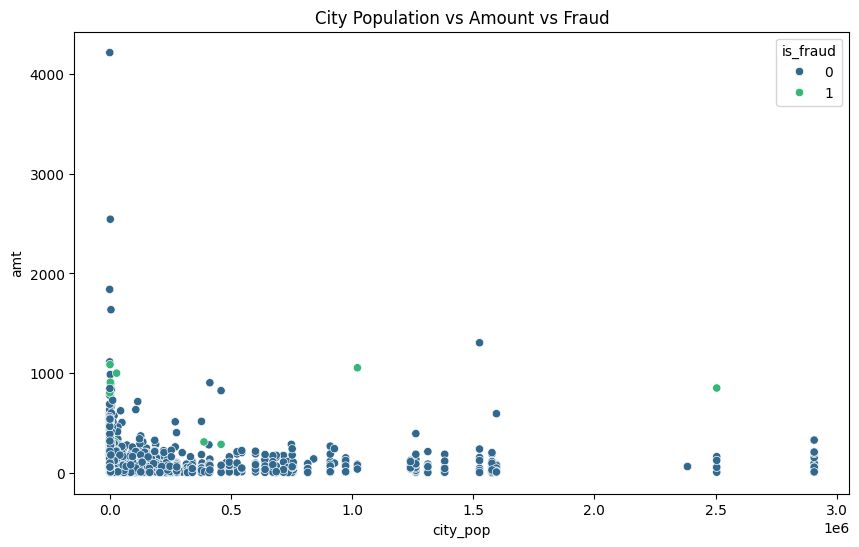

In [27]:
# City Population vs Amount vs Fraud
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x='city_pop',
    y='amt',
    hue='is_fraud',
    palette='viridis'
)

plt.title('City Population vs Amount vs Fraud')
plt.show()

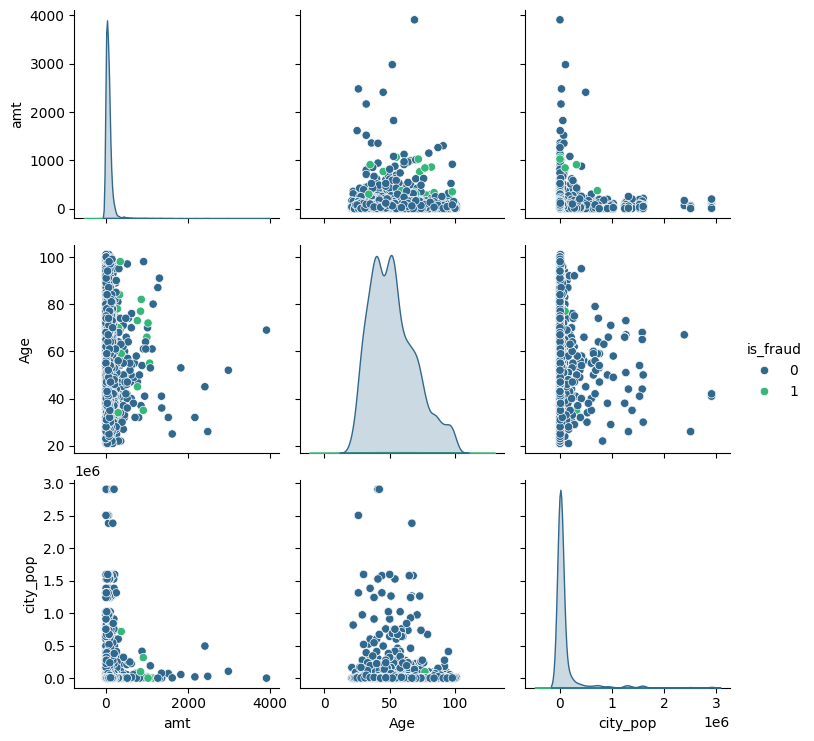

In [28]:
# Pairplot (Important Interview Visualization)

sample_df = df.sample(5000)

sns.pairplot(
    sample_df[
        ['amt',
         'Age',
         'city_pop',
         'is_fraud']
    ],
    hue='is_fraud',
    palette='viridis'
)

plt.show()

## Other Visualisations

In [29]:
fraud_percent = (
df['is_fraud'].value_counts(normalize=True)*100
)

print(fraud_percent)

is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


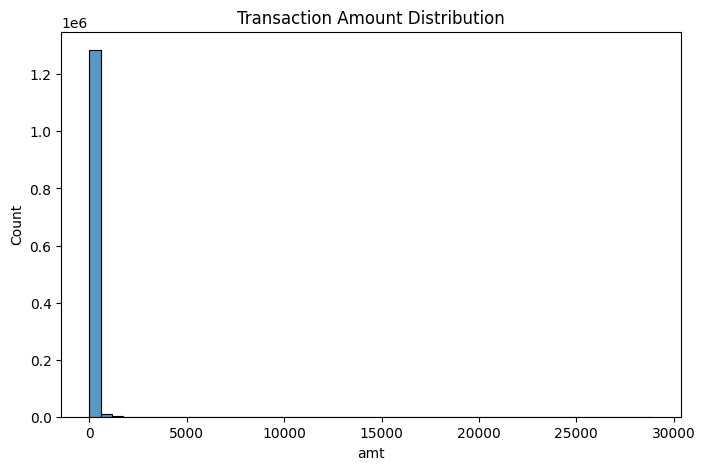

In [30]:
# Transaction Amount Analysis

plt.figure(figsize=(8,5))

sns.histplot(df['amt'], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

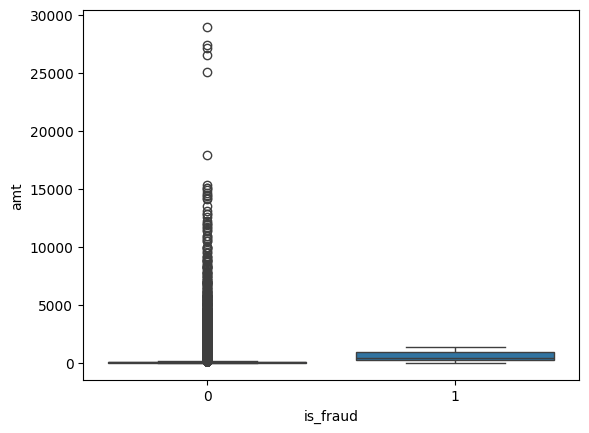

In [31]:
# Fraud Amount Comparison

sns.boxplot(
x='is_fraud',
y='amt',
data=df
)

plt.show()

In [32]:
# Top Categories

top_categories = (
df.groupby('category')['amt']
.sum()
.sort_values(ascending=False)
.head(10)
)

print(top_categories)

category
grocery_pos      14460822.38
shopping_pos      9307993.61
shopping_net      8625149.68
gas_transport     8351732.29
home              7173928.11
kids_pets         6503680.16
entertainment     6036678.56
misc_net          5117709.26
misc_pos          5009582.50
food_dining       4672459.44
Name: amt, dtype: float64


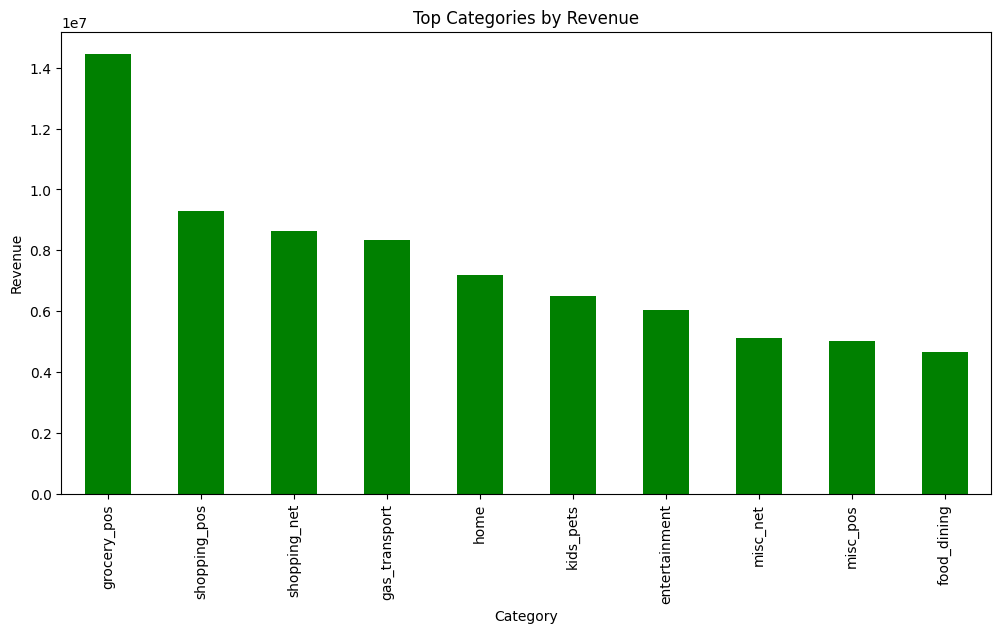

In [33]:
top_categories.plot(
    kind='bar',
    figsize=(12,6),
    color='green'
)

plt.title("Top Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [34]:
# top_merchants 
top_merchants = (df.groupby('merchant')['amt'].sum().sort_values(ascending=False).head(10))

print(top_merchants)

merchant
fraud_Kilback LLC                   391078.15
fraud_Bradtke PLC                   302481.25
fraud_Doyle Ltd                     300971.37
fraud_Hackett-Lueilwitz             300208.14
fraud_Schumm, Bauch and Ondricka    299115.14
fraud_Rau and Sons                  298354.77
fraud_Goodwin-Nitzsche              298083.31
fraud_Pacocha-O'Reilly              297584.38
fraud_Murray-Smitham                296982.73
fraud_Bauch-Raynor                  295721.20
Name: amt, dtype: float64


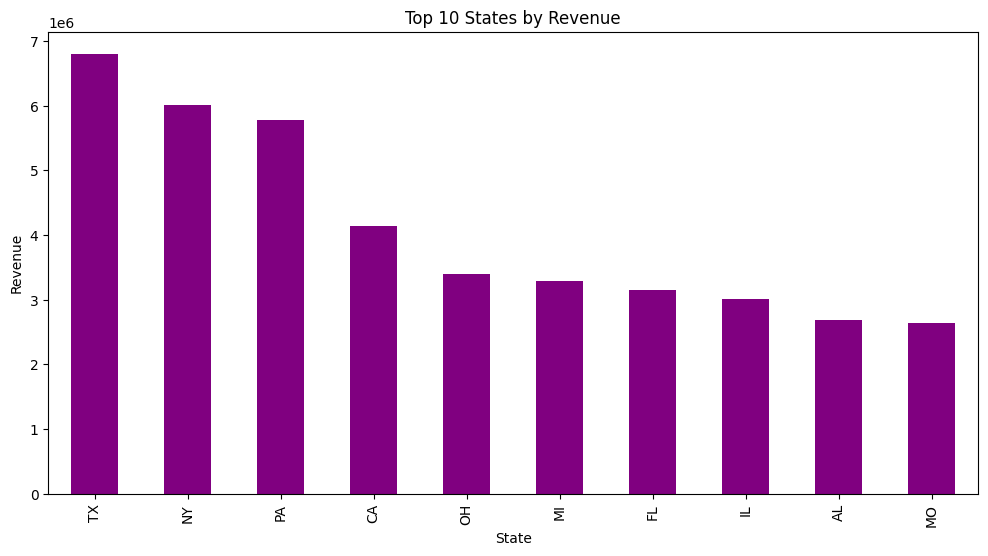

In [35]:
# State Analysis

state_revenue = (
    df.groupby('state')['amt']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_revenue.plot(
    kind='bar',
    figsize=(12,6),
    color='purple'
)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

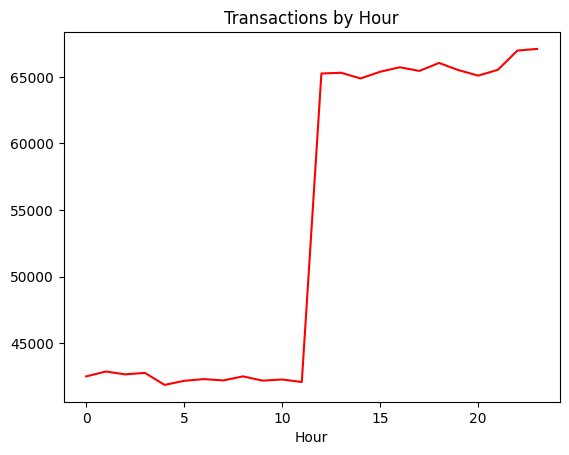

In [36]:
# Hour-wise Transactions

hourly = (
df.groupby('Hour')['amt']
.count()
)

hourly.plot(color='red')

plt.title("Transactions by Hour")

plt.show()

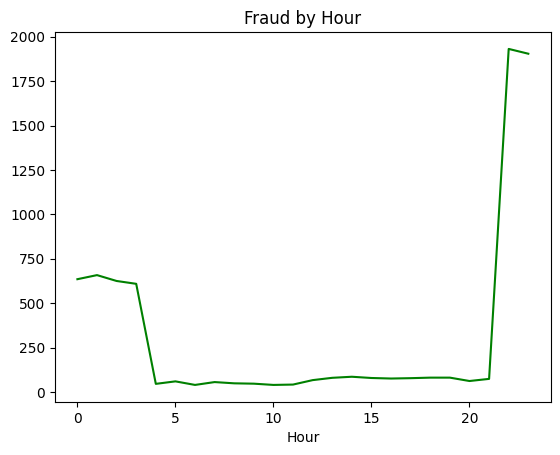

In [37]:
# Hour-wise Fraud

fraud_hour = (
df[df['is_fraud']==1]
.groupby('Hour')
.size()
)

fraud_hour.plot(color='green')

plt.title("Fraud by Hour")

plt.show()

## Creating new columns for ML Fraud detection

In [38]:
print(df['trans_date_trans_time'].dtype)

object


In [39]:
df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time']
)

In [40]:
df['Amount_Group'] = pd.cut(
    df['amt'],
    bins=[0,50,100,500,1000,5000,50000],
    labels=['Very Low','Low','Medium','High','Very High','Extreme']
)

In [41]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour,Amount_Group
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,36.0788,-81.1781,...,36.011293,-82.048315,0,38,26-40,2019,January,Tuesday,0,Very Low
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,...,49.159047,-118.186462,0,48,41-60,2019,January,Tuesday,0,Medium
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,42.1808,-112.2620,...,43.150704,-112.154481,0,64,60+,2019,January,Tuesday,0,Medium
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,46.2306,-112.1138,...,47.034331,-112.561071,0,59,41-60,2019,January,Tuesday,0,Very Low
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,38.4207,-79.4629,...,38.674999,-78.632459,0,40,26-40,2019,January,Tuesday,0,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,M,Hatch,UT,37.7175,-112.4777,...,36.841266,-111.690765,0,64,60+,2020,June,Sunday,12,Very Low
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,M,Tuscarora,MD,39.2667,-77.5101,...,38.906881,-78.246528,0,46,41-60,2020,June,Sunday,12,Low
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,M,High Rolls Mountain Park,NM,32.9396,-105.8189,...,33.619513,-105.130529,0,58,41-60,2020,June,Sunday,12,Medium
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,M,Manderson,SD,43.3526,-102.5411,...,42.788940,-103.241160,0,45,41-60,2020,June,Sunday,12,Low


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  object        
 6   city                   1296675 non-null  object        
 7   state                  1296675 non-null  object        
 8   lat                    1296675 non-null  float64       
 9   long                   1296675 non-null  float64       
 10  city_pop               1296675 non-null  int64         
 11  job                    1296675 non-null  object        
 12  dob                    12966

In [43]:
# 2: Encode Categorical Variables

# Check Unique Values
categorical_cols = [
    'category',
    'gender',
    'state',
    'job',
    'Age_Group',
    'Month',
    'Day'
]

for col in categorical_cols:
    print(col, ":", df[col].nunique())

category : 14
gender : 2
state : 51
job : 494
Age_Group : 4
Month : 12
Day : 7


In [44]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'category',
    'gender',
    'state',
    'job',
    'Age_Group',
    'Month',
    'Day'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  int64         
 4   amt                    1296675 non-null  float64       
 5   gender                 1296675 non-null  int64         
 6   city                   1296675 non-null  object        
 7   state                  1296675 non-null  int64         
 8   lat                    1296675 non-null  float64       
 9   long                   1296675 non-null  float64       
 10  city_pop               1296675 non-null  int64         
 11  job                    1296675 non-null  int64         
 12  dob                    12966

In [46]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,lat,long,...,merch_lat,merch_long,is_fraud,Age,Age_Group,Year,Month,Day,Hour,Amount_Group
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",8,4.97,0,Moravian Falls,27,36.0788,-81.1781,...,36.011293,-82.048315,0,38,1,2019,4,5,0,Very Low
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",4,107.23,0,Orient,47,48.8878,-118.2105,...,49.159047,-118.186462,0,48,2,2019,4,5,0,Medium
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,0,220.11,1,Malad City,13,42.1808,-112.2620,...,43.150704,-112.154481,0,64,3,2019,4,5,0,Medium
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",2,45.00,1,Boulder,26,46.2306,-112.1138,...,47.034331,-112.561071,0,59,2,2019,4,5,0,Very Low
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,9,41.96,1,Doe Hill,45,38.4207,-79.4629,...,38.674999,-78.632459,0,40,1,2019,4,5,0,Very Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,0,15.56,1,Hatch,44,37.7175,-112.4777,...,36.841266,-111.690765,0,64,3,2020,6,3,12,Very Low
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,1,51.70,1,Tuscarora,20,39.2667,-77.5101,...,38.906881,-78.246528,0,46,2,2020,6,3,12,Low
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,1,105.93,1,High Rolls Mountain Park,32,32.9396,-105.8189,...,33.619513,-105.130529,0,58,2,2020,6,3,12,Medium
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",1,74.90,1,Manderson,41,43.3526,-102.5411,...,42.788940,-103.241160,0,45,2,2020,6,3,12,Low


After SMOTE
is_fraud
0    1031335
1    1031335
Name: count, dtype: int64

All Models Trained Successfully

Best Random Forest
RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=200,
                       random_state=42)

Best XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
             

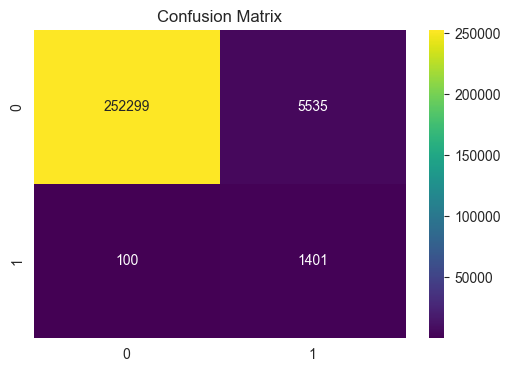

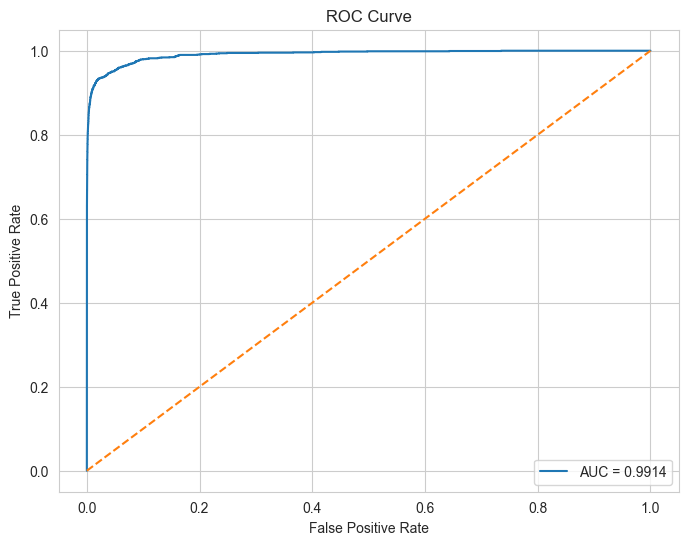

In [54]:

# STEP 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import joblib

sns.set_style("whitegrid")



# STEP 2: FEATURES & TARGET


features = [
    'amt',
    'Age',
    'Hour',
    'city_pop',
    'category',
    'gender',
    'state',
    'job'
]

X = df[features]

y = df['is_fraud']



# STEP 3: TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)



# STEP 4: SMOTE


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE")
print(y_train_smote.value_counts())



# STEP 5: STANDARD SCALER


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)



# STEP 6: MODEL SELECTION


lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

dt = DecisionTreeClassifier(
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)


# STEP 7: MODEL TRAINING


lr.fit(
    X_train_scaled,
    y_train_smote
)

dt.fit(
    X_train_smote,
    y_train_smote
)

rf.fit(
    X_train_smote,
    y_train_smote
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

print("\nAll Models Trained Successfully")



# STEP 8: RANDOM FOREST TUNING


rf_params = {
    'n_estimators':[100,200],
    'max_depth':[10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    cv=3,
    scoring='f1',
    n_iter=5,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(
    X_train_smote,
    y_train_smote
)

best_rf = rf_search.best_estimator_

print("\nBest Random Forest")
print(best_rf)


# STEP 9: XGBOOST TUNING


xgb_params = {
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.05,0.1],
    'subsample':[0.8,1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_distributions=xgb_params,
    cv=3,
    scoring='f1',
    n_iter=5,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(
    X_train_smote,
    y_train_smote
)

best_xgb = xgb_search.best_estimator_

print("\nBest XGBoost")
print(best_xgb)



# STEP 10: MODEL COMPARISON


models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():

    if name == "Logistic Regression":

        y_pred = model.predict(
            X_test_scaled
        )

        probs = model.predict_proba(
            X_test_scaled
        )[:,1]

    else:

        y_pred = model.predict(
            X_test
        )

        probs = model.predict_proba(
            X_test
        )[:,1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        probs
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

print("\nMODEL COMPARISON")
print(results_df)



# STEP 11: BEST MODEL


best_model = best_xgb

y_pred = best_model.predict(
    X_test
)

probs = best_model.predict_proba(
    X_test
)[:,1]

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred
    )
)



# STEP 12: CONFUSION MATRIX


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis'
)

plt.title("Confusion Matrix")

plt.show()


# STEP 13: ROC CURVE


fpr, tpr, thresholds = roc_curve(
    y_test,
    probs
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, probs):.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()




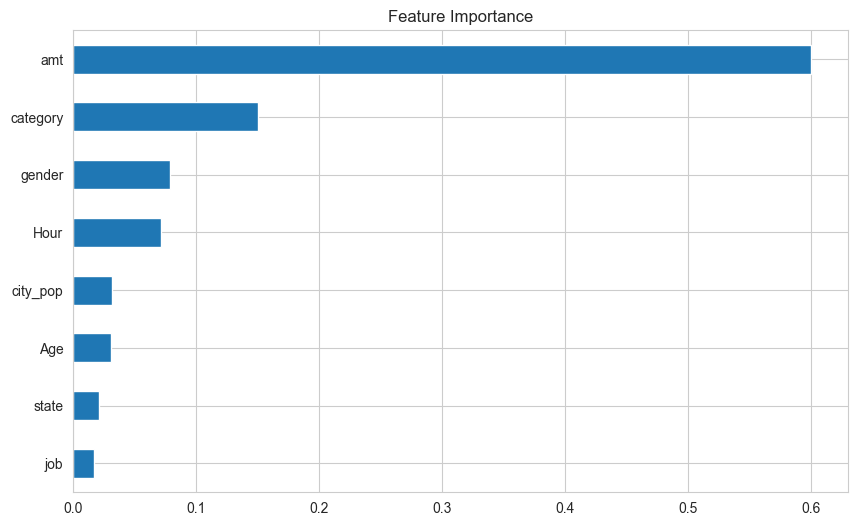

In [55]:

# FEATURE IMPORTANCE


importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()



In [56]:

# SAVE MODEL


import joblib

joblib.dump(
    best_xgb,
    "full_dataset_fraud_model.pkl"
)

print("\nModel Saved Successfully")





Model Saved Successfully
